## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 5 (Section 004 - Spring 2022)

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.



<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

___
# Late uploads will be graded as 0 points.

Please finish uploading this quiz notebook to D2L before 3:34:59 p.m.

You can upload this notebook to D2L multiple times during the quiz, but only the last update counts.

If you get less than 70 regular points, you cannot get benifit from bonus points.

___
### &#9989;&nbsp; Question 0: Importing modules (5 points)

Please **import** all modules you need in this quiz in the following cell. Do not import unnecessary ones.

You may come back to this question later on. Keep this in mind.

In [1]:
# Put your code here

In [5]:
### Answer ###

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp 

### Answer ###

___

# Modeling Saltwater in a Tank

Let's consider the following toy model.

Considering a tank of fixed volume $V$ (in unit $\textrm{m}^3$) that is full of salt water. 
Additional salt water, with fixed salt concentration $A$ (in unit $\textrm{kg} / \textrm{m}^{3}$), is pumped into this tank with constant rate $P$ (in unit $\textrm{m}^3 / \textrm{s}$), and is pumpted out at the same rate so that the tank is always full.

When the salt water is pumped into the tank, We assume the salt concentration achieves balance immediately, so that the salt water pumpted out has the same salt concentration as the sal twater in the tank. Moreover, the salt itself does not take any volume, only the water does.

The mass of total salt in the tank, $S$ (in unit $\textrm{kg}$), is a variable with respect to the time.

___
### &#9989;&nbsp; Question 1: Modeling (20 points)

Now the compartmental model has only one compart $S(t)$ depending on time $t$, and two arrows, i.e., rate of incoming salt mass $X(t)$ and rate of outflowing salt mass $Y(t)$ (both in unit $\textrm{kg} / \textrm{s}$), so that the model can be illustrated as

$$
\stackrel{\tiny{X}}{\rightarrow}
S
\stackrel{\tiny{Y}}{\rightarrow}
$$

Based on the model, we can derive, for example
$$
X(t) \equiv AP,
$$
please **derive** $Y(t)$ in terms of given quantities $V$, $A$, $P$, and $S (t)$.

<font size=+3>&#9998;</font> *Put your answer here.*
- Y(t) =

`### Answer ###`

$$Y(t) = PS(t)/V.$$

`### Answer ###`

___
### &#9989;&nbsp; Question 2: Derivative function (20 points)

Now the ODE reads
$$
S'(t) = X(t) - Y(t).
$$

Please **develop** a corresponding derivative function `derivs` which will be used in `solve_ivp` in Question 3.

In coding, $X$ and $Y$ should be replaced by the solution of Question 1.

In [2]:
# Put your code here

In [3]:
### Answer ###

def derivs(t, curr_vals, V, A, P):
    S = curr_vals[0]
    X = A * P
    Y = S * P / V
    dSdt = X - Y
    return dSdt

### Answer ###

___
### &#9989;&nbsp; Question 3: Numerical solution (20 points)
       
Given the initial salt mass in the tank $S(0) = 2 \textrm{kg}$, 
the tank volume $V = 1 \textrm{m}^{3}$, 
the salt concentration of the incoming salt water $A = 1\textrm{kg} / \textrm{m}^{3}$, 
and the flow rate $P = 1 \textrm{m}^3 / \textrm{s}$,
please numerically **solve** the ODE using `solve_ivp` function, 
and **plot** the solution $S(t)$. When plotting, please include necessary information.

Please use time step as $0.1 \textrm{s}$ and solve the model till time equals to $10 \textrm{s}$.

In [9]:
# Put your code here

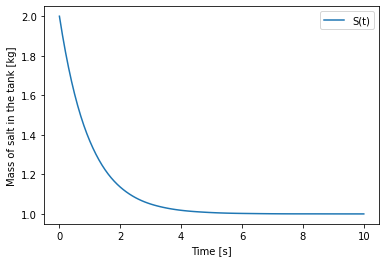

In [10]:
### Answer ###

S0 = 2

init = [S0]

V = 1
A = 1
P = 1

tmax = 10
dt = 0.1
time = np.arange(0, tmax + dt, dt)

sol = solve_ivp(derivs, (0, tmax), init, t_eval = time, args = [V, A, P])

fig = plt.figure(figsize = (6, 4))
plt.plot(sol.t, sol.y[0], label='S(t)')
plt.xlabel('Time [s]')
plt.ylabel('Mass of salt in the tank [kg]')
plt.legend()

### Answer ###

___
### &#9989;&nbsp; Question 4: Explanation (15 points)

Based on your understanding to the model and the setting in Question 3, please use plain English to **explain** why your curve in the plot is reasonable.

Your explanation should at least cover the initial state, the trend, and the final state. The explanation is not just a description of the plot.

Hint: You may think about the salt concentration.

<font size=+3>&#9998;</font> *Put your answer here.*
- Answer

`### Answer ###`

The tank is full of high concentration salt water, $2 \textrm{kg} / \textrm{m} ^{3}$, and the low concentration salt water $1 \textrm{kg} / \textrm{m} ^{3}$ is pumped in for a long time, so that the final salt concentration in the tank decreases and does converge to the incoming flow concentration.

`### Answer ###`

___
### &#9989;&nbsp; Question 3': Two connected tanks (20 bonus points)

Now we split the tank into two tanks, each with volume $V / 2$ (in unit $\textrm{m}^3$). The incoming salt water is pumped into the first tank, and the outflowing flow of the first tank is going to the second tank, and then pumped out. Please see the following illustration
$$
\stackrel{\tiny{X}}{\rightarrow}
S
\stackrel{\tiny{Y}}{\rightarrow}
T
\stackrel{\tiny{Z}}{\rightarrow}
$$
where $S$ and $T$ are total mass of salt in two tanks.

Please numerically **solve** the corresponding ODE system using the similar setting in Question 3, that means, $S(0) = T(0) = 1 \textrm{kg}$, $V / 2 = 0.5 \textrm{m}^{3}$, $A = 1\textrm{kg} / \textrm{m}^{3}$, $P = 1 \textrm{m}^3 / \textrm{s}$, and **plot** your results.

In [14]:
# Put your code here

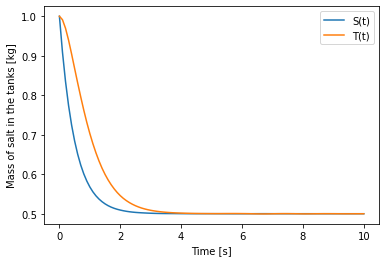

In [14]:
### Answer ###

def derivs2(t, curr_vals, V, A, P):
    S = curr_vals[0]
    T = curr_vals[1]
    X = A * P
    Y = S * P / (V / 2)
    Z = T * P / (V / 2)
    dSdt = X - Y
    dTdt = Y - Z
    return dSdt, dTdt

S0 = 1
T0 = 1

init = [S0, T0]

V = 1
A = 1
P = 1

tmax = 10
dt = 0.1
time = np.arange(0, tmax + dt, dt)

sol = solve_ivp(derivs2, (0, tmax), init, t_eval = time, args = [V, A, P])

fig = plt.figure(figsize = (6, 4))
plt.plot(sol.t, sol.y[0], label = 'S(t)')
plt.plot(sol.t, sol.y[1], label = 'T(t)')
# plt.plot(sol.t, sol.y[0] + sol.y[1], label = 'S(t)+T(t)')
plt.xlabel('Time [s]')
plt.ylabel('Mass of salt in the tanks [kg]')
plt.legend()

### Answer ###

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page. Go to "Quizzes" -> "Quiz 5" -> "Please drop your Quiz 5 notebook here", and upload your notebook there.